**DAV-LAB\
NAME-VAISHNAV BALPANDE\
SECTION-5B\
ROLL NO-01\
PRAC3-ASSIGNMENT**

**Practical 3: Data Transformation and Analysis\
Aim:-To perform various data transformation and data analysis techniques using the prices.csv dataset.**

****Step 1: Import Required Libraries****

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

****Step 2: Dataset Selection****

In [18]:
dataset_path='prices.csv'
print(f"Using dataset: {dataset_path}")

Using dataset: prices.csv


****Step 3: Load the Dataset****

In [19]:
df=pd.read_csv(dataset_path)
display(df.head())

,Price Dates,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
0,01-01-2023,35.0,18,22.0,20,30,50,25,8,45.0,25
1,02-01-2023,35.0,16,22.0,20,30,55,25,7,40.0,25
2,03-01-2023,35.0,16,21.0,20,30,55,25,7,40.0,25
3,04-01-2023,30.0,16,21.0,22,25,55,25,7,40.0,25
4,08-01-2023,35.0,16,20.0,21,25,55,22,6,35.0,25


****Step 4: Explore the Dataset****

In [20]:
print("--- First Few Rows ---")
display(df.head())

print("\n--- Last Few Rows ---")
display(df.tail())

print("\n--- Number of Rows and Columns ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum().head(10))

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

--- First Few Rows ---


,Price Dates,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
0,01-01-2023,35.0,18,22.0,20,30,50,25,8,45.0,25
1,02-01-2023,35.0,16,22.0,20,30,55,25,7,40.0,25
2,03-01-2023,35.0,16,21.0,20,30,55,25,7,40.0,25
3,04-01-2023,30.0,16,21.0,22,25,55,25,7,40.0,25
4,08-01-2023,35.0,16,20.0,21,25,55,22,6,35.0,25



--- Last Few Rows ---


,Price Dates,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
282,27-12-2023,45.0,16,30.0,20,70,260,40,16,40.0,25
283,28-12-2023,45.0,16,30.0,20,70,260,30,20,45.0,25
284,29-12-2023,45.0,16,30.0,22,80,260,30,18,50.0,25
285,31-12-2023,45.0,16,26.0,20,60,250,40,16,50.0,40
286,01-01-2024,45.0,16,9.0,18,50,260,40,15,60.0,25



--- Number of Rows and Columns ---
(287, 11)

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price Dates           287 non-null    str    
 1   Bhindi                287 non-null    float64
 2   Tomato                287 non-null    int64  
 3   Onion                 287 non-null    float64
 4   Potato                287 non-null    int64  
 5   Brinjal               287 non-null    int64  
 6   Garlic                287 non-null    int64  
 7   Peas                  287 non-null    int64  
 8   Methi                 287 non-null    int64  
 9   Green Chilli          287 non-null    float64
 10  Elephant Yam (Suran)  287 non-null    int64  
dtypes: float64(3), int64(7), str(1)
memory usage: 24.8 KB
None

--- Missing Values ---
Price Dates     0
Bhindi          0
Tomato          0
Onion           0
Potato          0

,Price Dates,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
count,287,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000
unique,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,01-01-2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,29.444251,16.006969,20.649826,18.585366,31.655052,133.101045,66.658537,20.383275,44.122404,28.797909
std,NaN,8.124815,0.118056,11.711204,2.726238,11.725421,60.078331,33.302415,117.428417,12.796590,6.607973
min,NaN,17.000000,16.000000,8.000000,12.000000,14.000000,50.000000,22.000000,5.000000,0.130000,12.000000
25%,NaN,22.000000,16.000000,12.000000,16.000000,25.000000,85.000000,40.000000,8.000000,35.000000,25.000000
50%,NaN,27.500000,16.000000,16.000000,20.000000,30.000000,120.000000,60.000000,12.000000,40.000000,30.000000
75%,NaN,33.000000,16.000000,25.000000,20.000000,35.000000,165.000000,80.000000,16.000000,50.000000,30.000000


****Step 5: Data Cleaning****

In [21]:
df['Price Dates']=pd.to_datetime(df['Price Dates'],format='%d-%m-%Y',errors='coerce')
df['Month']=df['Price Dates'].dt.month_name()

numeric_cols=df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
    df[col]=df[col].fillna(df[col].median())

df['Month']=df['Month'].fillna(df['Month'].mode()[0])
df=df.drop_duplicates()

display(df.head())
print("\nMissing values after cleaning:\n",df.isnull().sum())

,Price Dates,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran),Month
0,2023-01-01,35.0,18,22.0,20,30,50,25,8,45.0,25,January
1,2023-01-02,35.0,16,22.0,20,30,55,25,7,40.0,25,January
2,2023-01-03,35.0,16,21.0,20,30,55,25,7,40.0,25,January
3,2023-01-04,30.0,16,21.0,22,25,55,25,7,40.0,25,January
4,2023-01-08,35.0,16,20.0,21,25,55,22,6,35.0,25,January



Missing values after cleaning:
 Price Dates             0
Bhindi                  0
Tomato                  0
Onion                   0
Potato                  0
Brinjal                 0
Garlic                  0
Peas                    0
Methi                   0
Green Chilli            0
Elephant Yam (Suran)    0
Month                   0
dtype: int64


****Step 6: Normalization****

In [22]:
min_max_scaler=MinMaxScaler()
df['Tomato_Normalized']=min_max_scaler.fit_transform(df[['Tomato']])
display(df[['Tomato','Tomato_Normalized']].head())

,Tomato,Tomato_Normalized
0,18,1.0
1,16,0.0
2,16,0.0
3,16,0.0
4,16,0.0


****Step 7: Scaling****

In [23]:
standard_scaler=StandardScaler()
df['Potato_Scaled']=standard_scaler.fit_transform(df[['Potato']])
display(df[['Potato','Potato_Scaled']].head())

,Potato,Potato_Scaled
0,20,0.519802
1,20,0.519802
2,20,0.519802
3,22,1.254696
4,21,0.887249


****Step 8: Encoding****

In [24]:
label_encoder=LabelEncoder()
df['Month_Encoded']=label_encoder.fit_transform(df['Month'])
display(df[['Month','Month_Encoded']].head())

,Month,Month_Encoded
0,January,4
1,January,4
2,January,4
3,January,4
4,January,4


****Step 9: Aggregation****

In [25]:
agg_df=df.groupby('Month').agg({
    'Tomato':'mean',
    'Potato':'max',
    'Onion':'min'
})
display(agg_df)

,Tomato,Potato,Onion
Month,,,
April,16.000000,16,8.0
August,16.000000,21,16.0
December,16.000000,22,24.0
February,16.000000,17,11.0
January,16.111111,24,9.0
July,16.000000,21,16.0
June,16.000000,21,12.0
March,16.000000,15,9.0
May,16.000000,22,8.5


****Step 10: Binning****

In [26]:
tomato_bins=[0,20,50,float('inf')]
tomato_labels=['Low','Medium','High']
df['Tomato_Category']=pd.cut(df['Tomato'],bins=tomato_bins,labels=tomato_labels)
display(df[['Tomato','Tomato_Category']].head(10))

,Tomato,Tomato_Category
0,18,Low
1,16,Low
2,16,Low
3,16,Low
4,16,Low
5,16,Low
6,16,Low
7,16,Low
8,16,Low
9,16,Low


****Step 11: Statistical Analysis****

In [27]:
print("--- Central Tendency ---")
print("Mean Tomato Price:",df['Tomato'].mean())
print("Median Potato Price:",df['Potato'].median())
print("Mode Month:\n",df['Month'].mode().to_string())

print("\n--- Dispersion ---")
print("Standard Deviation of Onion:",df['Onion'].std())
print("Variance of Tomato:",df['Tomato'].var())
print("Range of Potato:",df['Potato'].max()-df['Potato'].min())

print("\n--- Distribution ---")
print("Minimum Tomato Price:",df['Tomato'].min())
print("Maximum Potato Price:",df['Potato'].max())
print("Quartiles for Onion:\n",df['Onion'].quantile([0.25,0.5,0.75]))

--- Central Tendency ---
Mean Tomato Price: 16.006968641114984
Median Potato Price: 20.0
Mode Month:
 0      March
1    October

--- Dispersion ---
Standard Deviation of Onion: 11.711203991075877
Variance of Tomato: 0.013937282229965164
Range of Potato: 12

--- Distribution ---
Minimum Tomato Price: 16
Maximum Potato Price: 24
Quartiles for Onion:
 0.25    12.0
0.50    16.0
0.75    25.0
Name: Onion, dtype: float64


****Step 12: Correlation Analysis****

,Bhindi,Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran),Tomato_Normalized,Potato_Scaled,Month_Encoded
Bhindi,1.000000,0.040505,0.135353,-0.142327,0.534585,0.211865,-0.391240,-0.022921,-0.209258,0.010470,0.040505,-0.142327,-0.365042
Tomato,0.040505,1.000000,0.006829,0.030737,-0.008361,-0.081934,-0.074097,-0.006247,0.004062,-0.034045,1.000000,0.030737,-0.026442
Onion,0.135353,0.006829,1.000000,0.380323,0.147386,0.755264,0.255033,-0.003529,-0.214595,0.300265,0.006829,0.380323,0.299448
Potato,-0.142327,0.030737,0.380323,1.000000,0.353733,0.419036,0.289854,0.047102,0.087301,0.225328,0.030737,1.000000,0.160646
Brinjal,0.534585,-0.008361,0.147386,0.353733,1.000000,0.367036,0.063371,0.011920,0.125150,0.096391,-0.008361,0.353733,-0.188766
Garlic,0.211865,-0.081934,0.755264,0.419036,0.367036,1.000000,0.224896,0.022124,-0.100149,0.299406,-0.081934,0.419036,0.105093
Peas,-0.391240,-0.074097,0.255033,0.289854,0.063371,0.224896,1.000000,0.052488,0.358317,0.202458,-0.074097,0.289854,0.319903
Methi,-0.022921,-0.006247,-0.003529,0.047102,0.011920,0.022124,0.052488,1.000000,0.176467,0.009018,-0.006247,0.047102,0.010420
Green Chilli,-0.209258,0.004062,-0.214595,0.087301,0.125150,-0.100149,0.358317,0.176467,1.000000,-0.063119,0.004062,0.087301,0.020746
Elephant Yam (Suran),0.010470,-0.034045,0.300265,0.225328,0.096391,0.299406,0.202458,0.009018,-0.063119,1.000000,-0.034045,0.225328,-0.083099


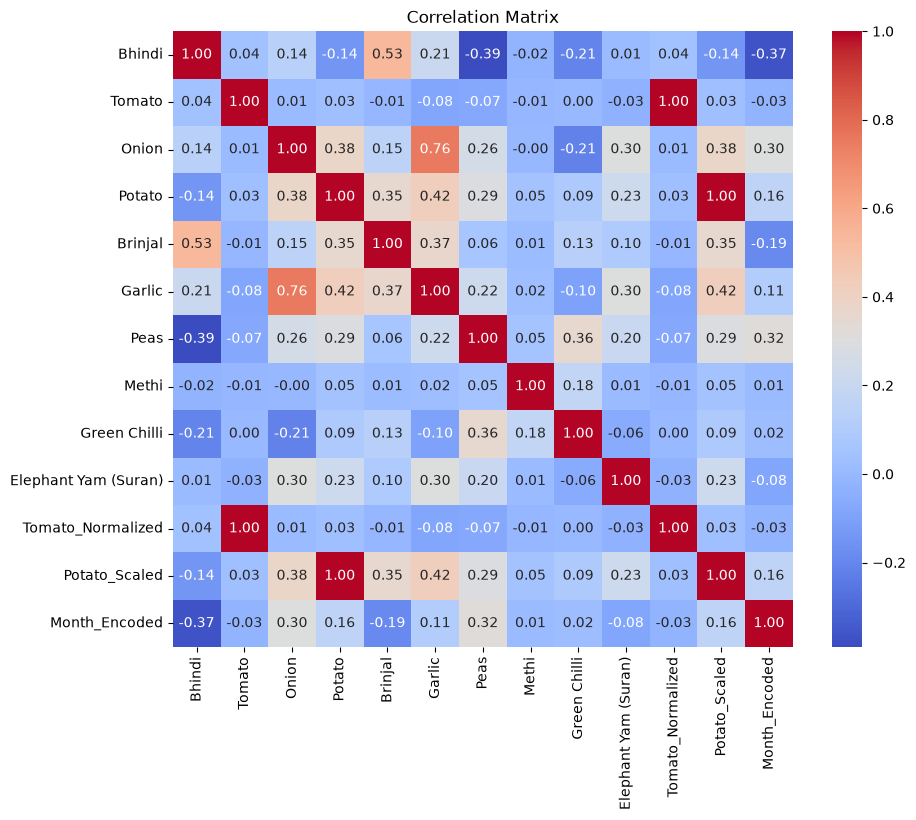

In [28]:
numerical_cols=df.select_dtypes(include=[np.number])
correlation_matrix=numerical_cols.corr()
display(correlation_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

****Step 13: Regression Analysis****

,Actual Onion,Predicted Onion
9,18.0,26.577847
255,42.0,26.577847
144,16.0,24.903441
213,25.0,23.229036
230,35.0,24.903441
197,25.0,19.880224
97,10.0,23.229036
73,9.0,16.531413
109,10.0,26.577847
33,11.0,14.857007



--- Model Performance ---
Model Coefficient (Slope): 1.6744057359852302
Model Intercept: -10.259079179254787
R-squared Score (Accuracy): 0.11969517851586109


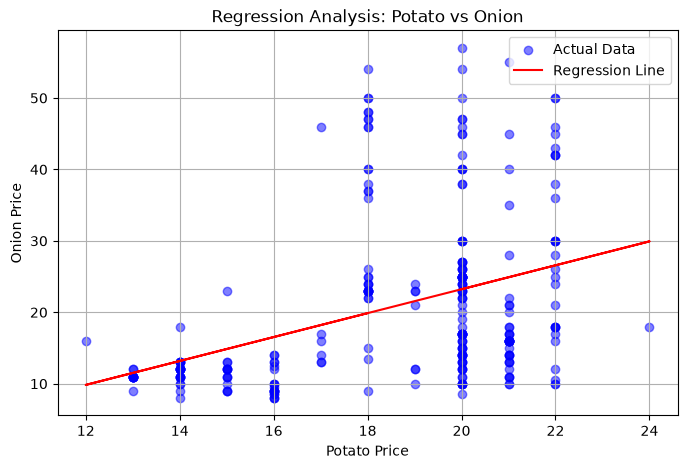

In [29]:
X=df[['Potato']]
y=df['Onion']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

comparison=pd.DataFrame({'Actual Onion':y_test,'Predicted Onion':y_pred})
display(comparison.head(10))

print("\n--- Model Performance ---")
print("Model Coefficient (Slope):",model.coef_[0])
print("Model Intercept:",model.intercept_)
print("R-squared Score (Accuracy):",model.score(X_test,y_test))

plt.figure(figsize=(8,5))
plt.scatter(X,y,color='blue',label='Actual Data',alpha=0.5)
plt.plot(X,model.predict(X),color='red',label='Regression Line')
plt.xlabel('Potato Price')
plt.ylabel('Onion Price')
plt.title('Regression Analysis: Potato vs Onion')
plt.legend()
plt.grid(True)
plt.show()